Explarotary Data Analysis & Confirmatory Data Analysis

## Description of Variables

### URL Features
*   **TLD**: The Top Level Domain (e.g., .com or .edu), which is the last part of the domain name.
*   **URLLength**: The total length of the URL, which is often longer in phishing attacks due to added subdirectories or parameters.
*   **IsDomainIP**: A binary feature indicating if the URL uses an IP address instead of a domain name.
*   **NoOfSubDomain**: The count of subdomains appearing before the domain name, often used to mimic legitimate sites.
*   **NoOfObfuscatedChar**: The count of obfuscated characters (e.g., using hex encoding like `%6d`) in the URL.
*   **IsHTTPS**: A feature indicating if the webpage uses the secured HTTPS protocol or unsecured HTTP.
*   **NoOfDigits**: The count of digits present in the URL.
*   **NoOfEquals**: The count of equal signs (`=`) in the URL.
*   **NoOfQMark**: The count of question marks (`?`) in the URL.
*   **NoOfAmp**: The count of ampersand or percent symbols in the URL.

### HTML Features
*   **LargestLineLength**: The length of the longest line of code in the HTML, used to detect code obfuscation.
*   **HasTitle**: A boolean indicating if the webpage contains a title tag.
*   **HasFavicon**: A boolean indicating if the website logo is included in the favicon tag.
*   **IsResponsive**: A feature indicating if the webpage is responsive and adapts across different devices.
*   **NoOfURLRedirect**: The count of redirects found in the HTML code (e.g., using `window.location` or `refresh` tags).
*   **HasDescription**: A boolean indicating if the webpage provides a description using the `description` meta name.
*   **NoOfPopup**: The count of pop-up windows (e.g., `window.open`) used on the page.
*   **NoOfiFrame**: The count of `iframe` tags, which are often used to capture sensitive information.
*   **HasExternalFormSubmit**: A feature indicating if an HTML form submits data to an external URL.
*   **HasCopyrightInfo**: A feature indicating the presence of copyright information on the webpage.
*   **HasSocialNet**: A feature indicating the presence of social networking links or information.
*   **HasPasswordField**: A boolean indicating the presence of password entry fields in the HTML.
*   **HasSubmitButton**: A boolean indicating the presence of a submit button tag.
*   **HasHiddenFields**: A feature indicating the use of hidden fields to capture information without user knowledge.
*   **Bank, Pay, Crypto**: Features indicating the presence of terms related to financial transactions or cryptocurrency, suggesting a request for sensitive financial info.
*   **NoOfImage**: The count of images used on the webpage.
*   **NoOfJS**: The count of JavaScript blocks embedded in the HTML.
*   **NoOfSelfRef**: The count of hyperlinks that navigate to the same webpage.
*   **NoOfSelfRedirect**: The number of times a webpage automatically reloads or redirects to the same URL.
*   **NoOfEmptyRef**: The count of hyperlinks that navigate to empty links.
*   **NoOfExternalRef**: The count of hyperlinks that navigate to external webpages.

### Derived Features
*   **CharContinuationRate**: A ratio calculated by summing the longest sequences of alphabets, digits, and special characters, divided by the total URL length.
*   **URLTitleMatchScore**: A score (0 to 100) indicating the discrepancy between the URL and the webpage title; a lower score may indicate phishing.
*   **URLCharProb**: A probability calculation based on the frequency of specific characters and digits in the URL compared to patterns in legitimate and phishing datasets.
*   **TLDLegitimateProb**: A probability ratio indicating how commonly the URL's TLD is associated with legitimate websites.

### Target Variable
*   **label**: The classification target where `1` represents a legitimate URL and `0` represents a phishing URL.

First Steps...

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Phishing_URL_ds_5percent_missing_train.csv')

In [12]:
#Split columns by Data Types
num_cols = df.select_dtypes(include=['float64', 'Int8']).columns
cat_cols = df.select_dtypes(include=['object']).columns
binary_columns = df.columns[df.columns.str.startswith("Has") | df.columns.str.startswith("Is")]
np.setdiff1d([col for col in df.columns if df[col].nunique() == 2], binary_columns)
binary_columns = binary_columns.union(["Bank", "Crypto", "Pay", "Robots"])

Univariate Summary Statistics

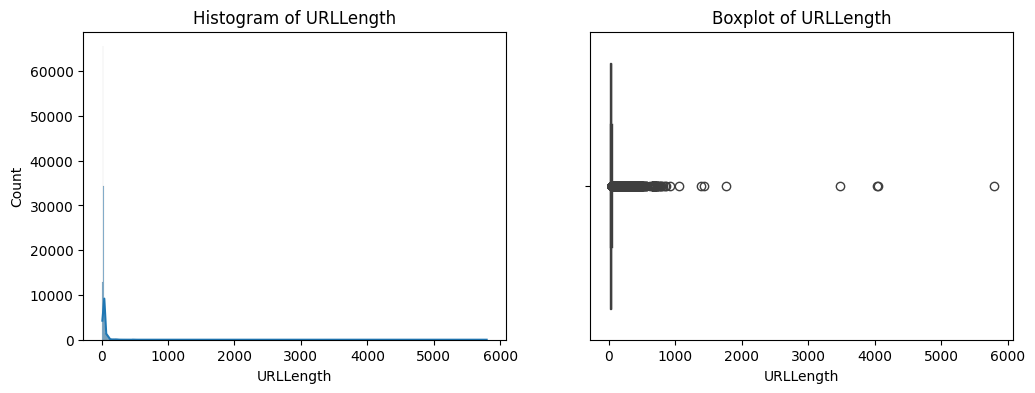

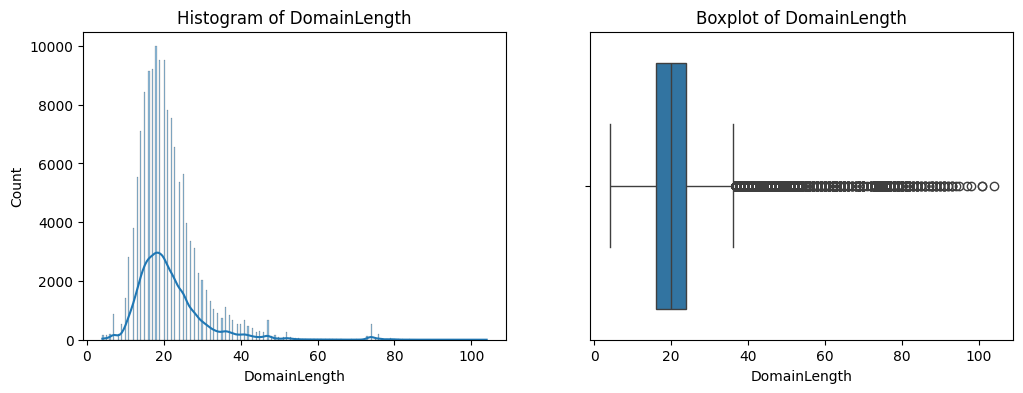

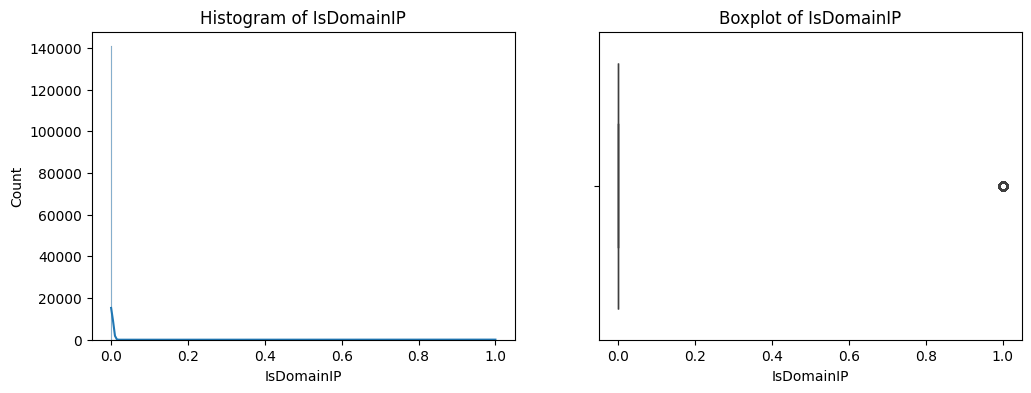

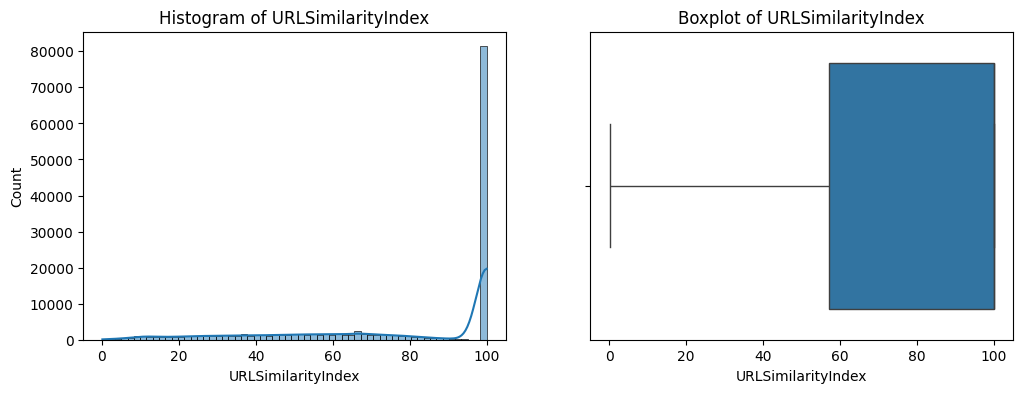

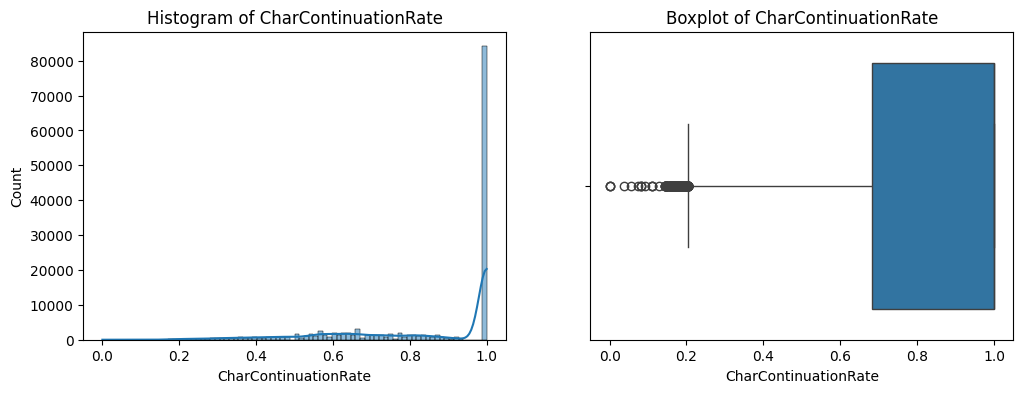

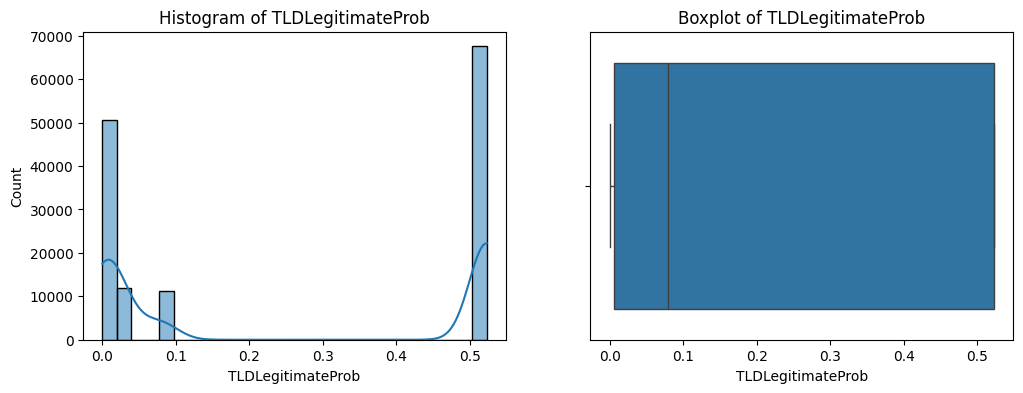

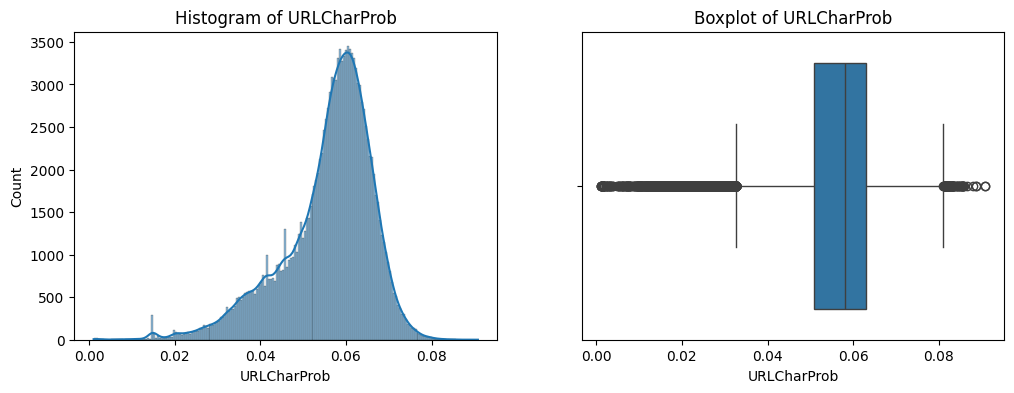

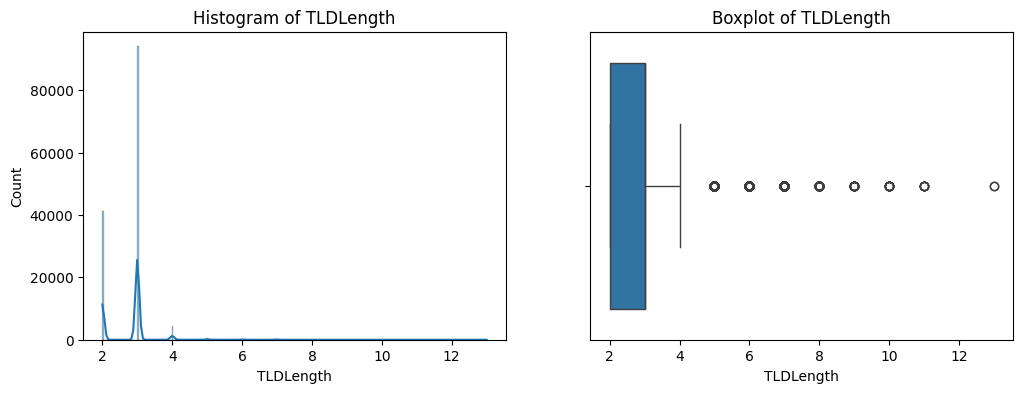

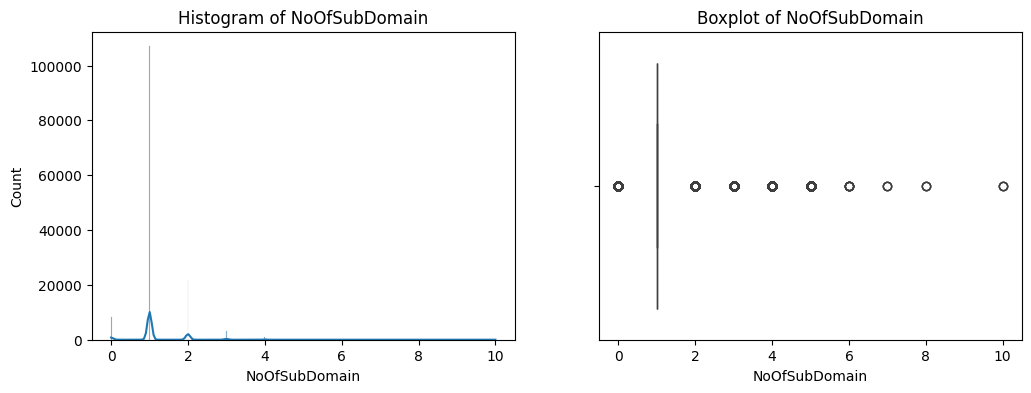

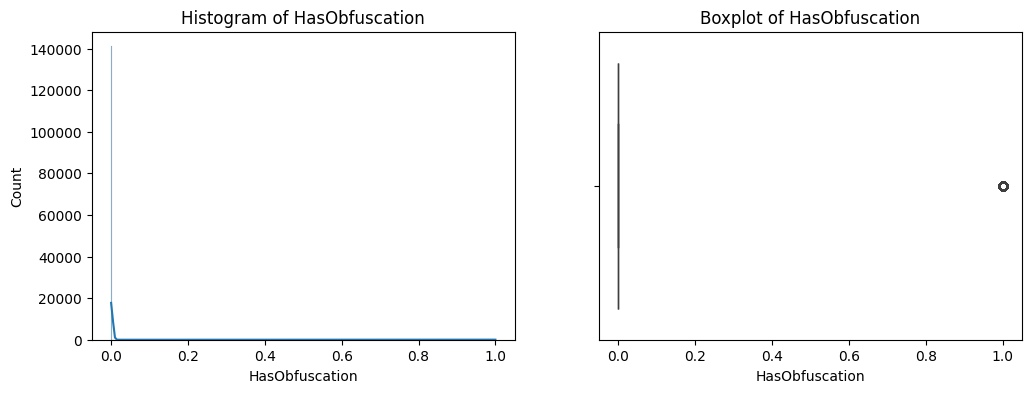

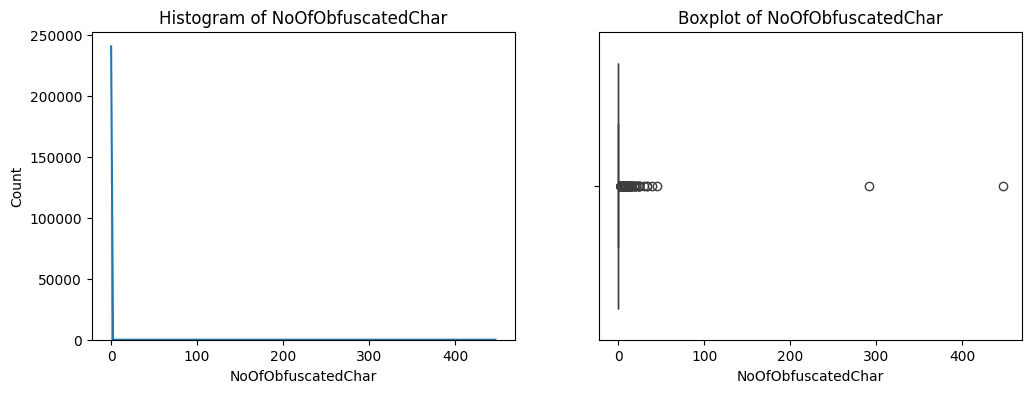

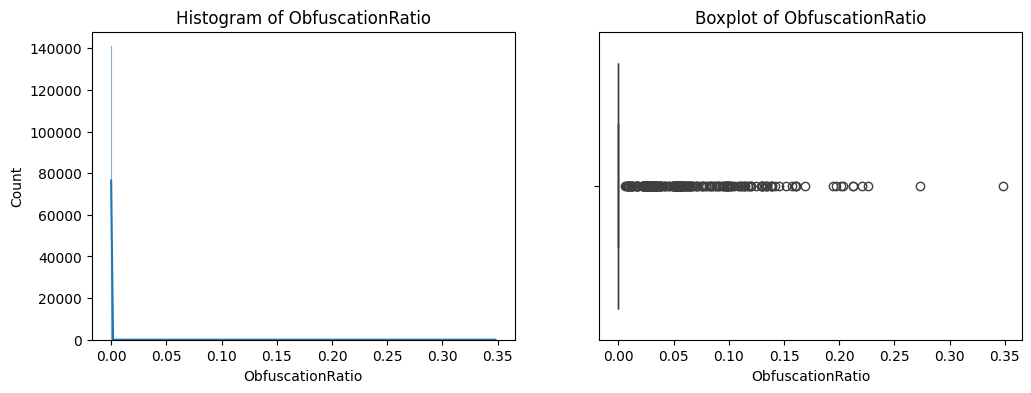

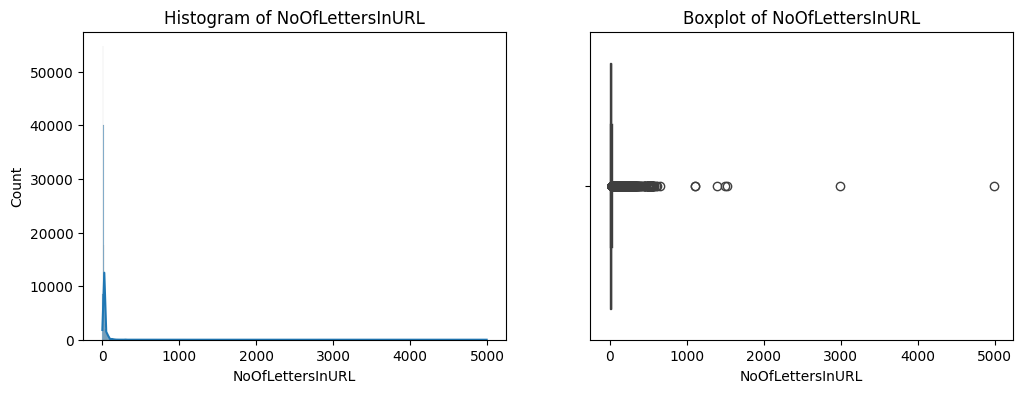

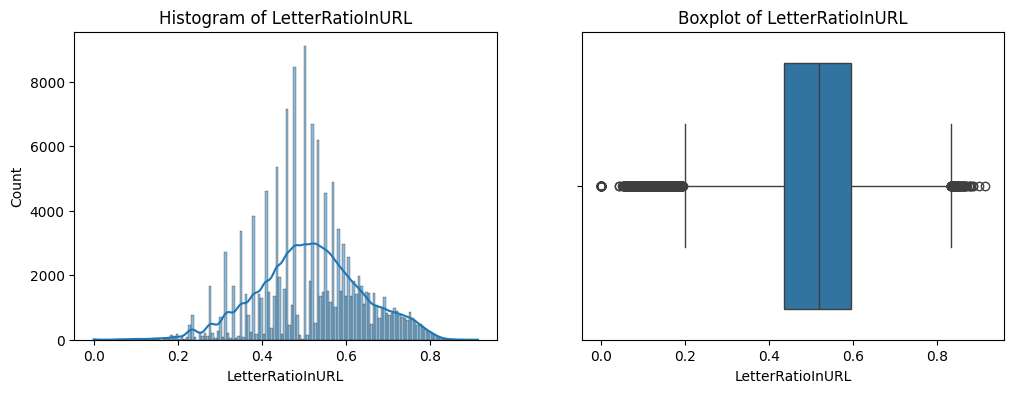

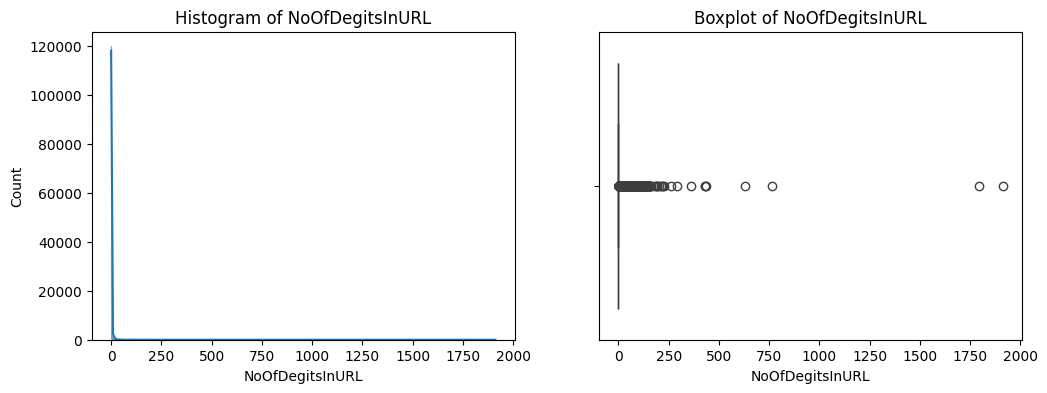

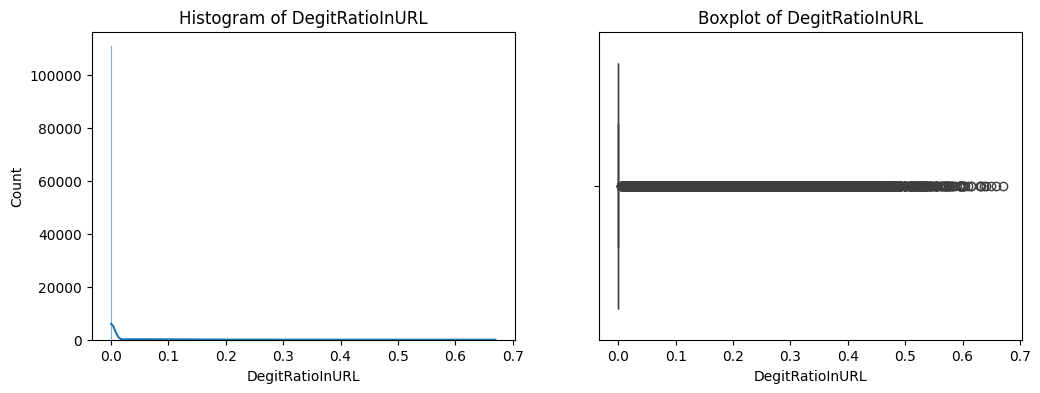

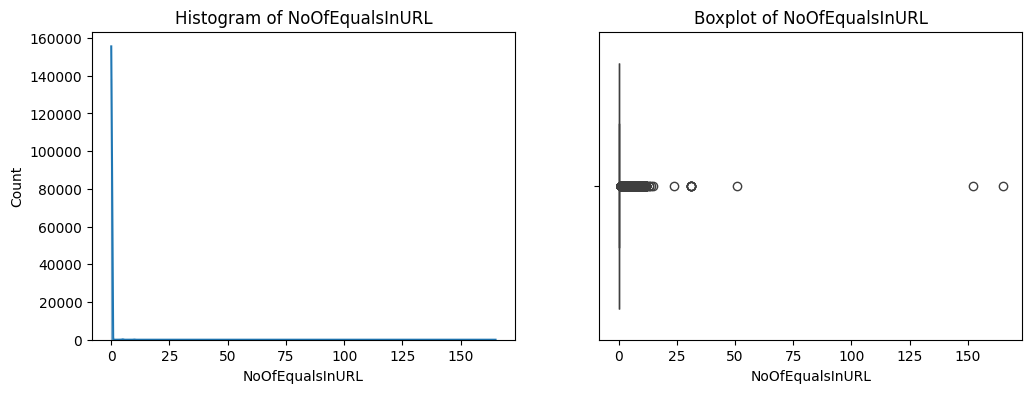

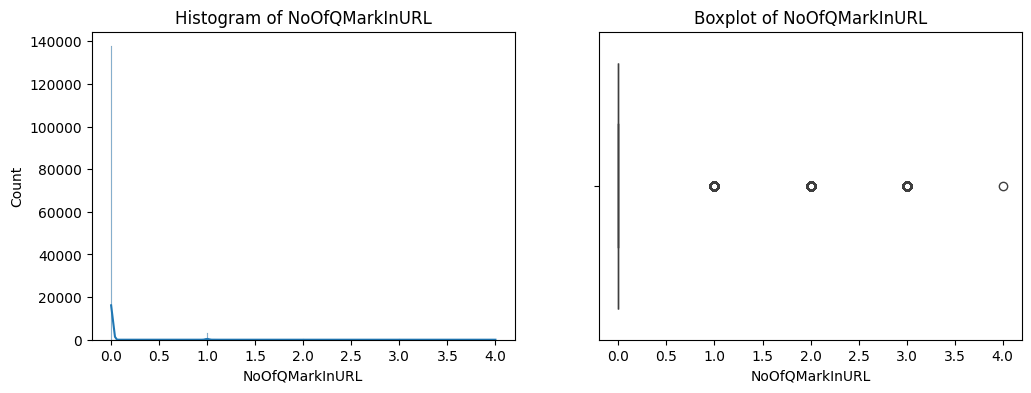

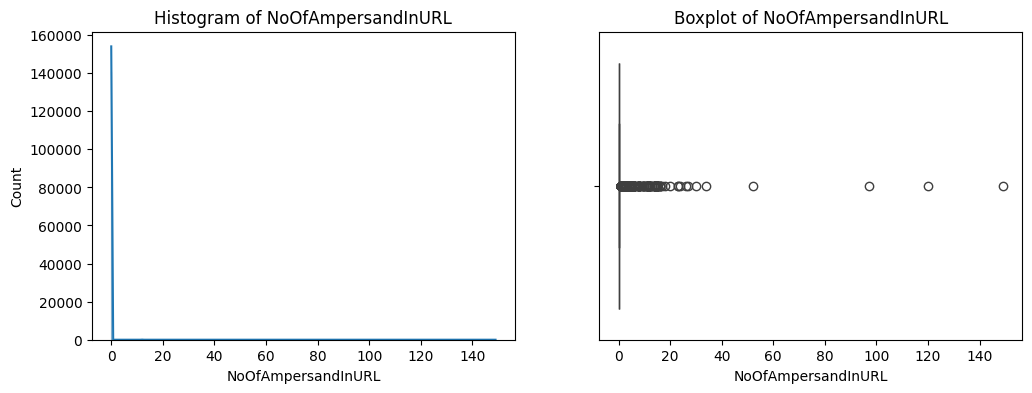

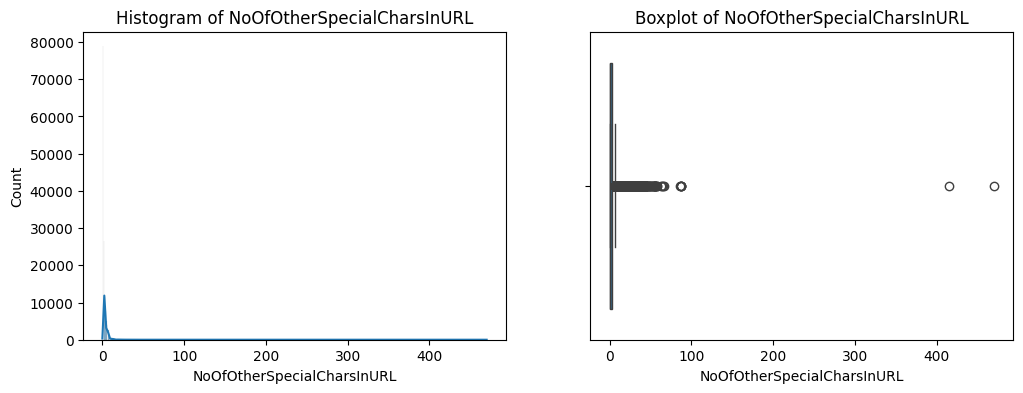

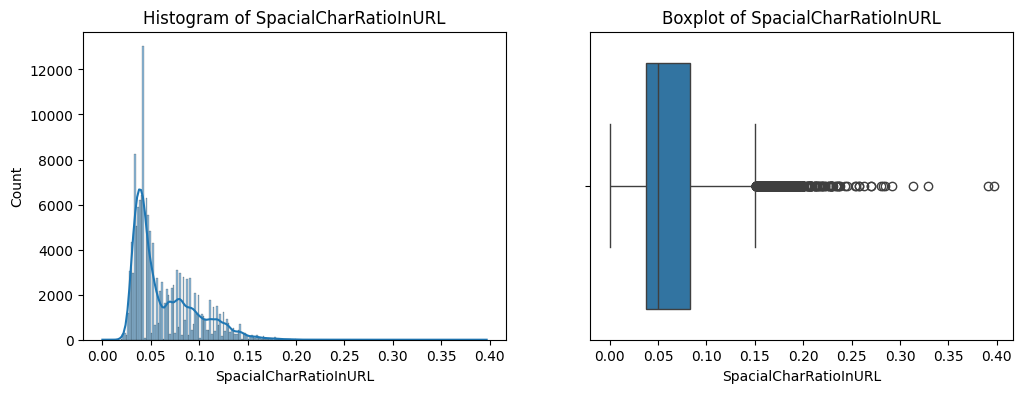

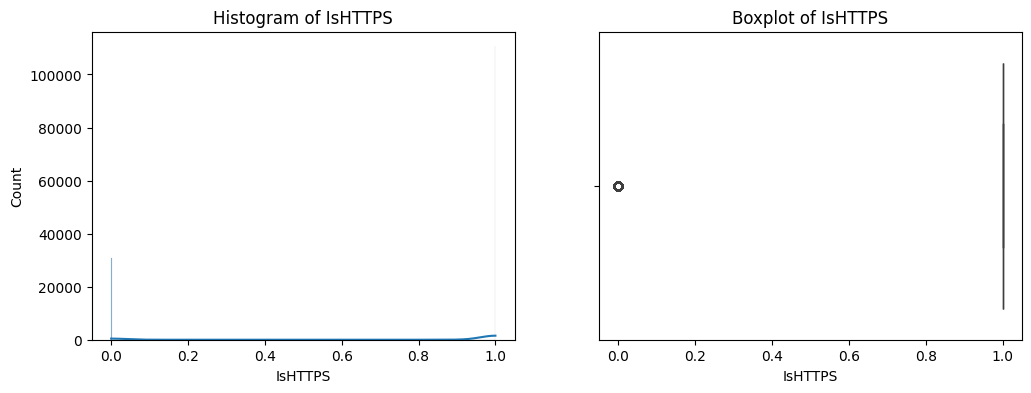

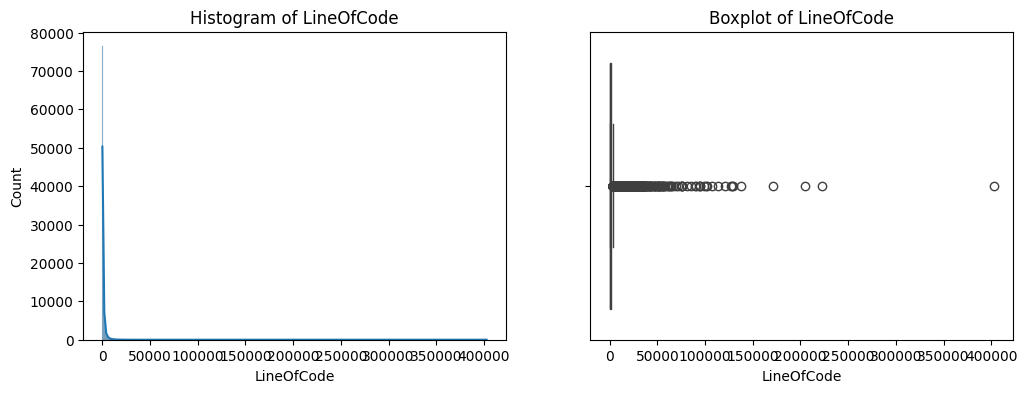

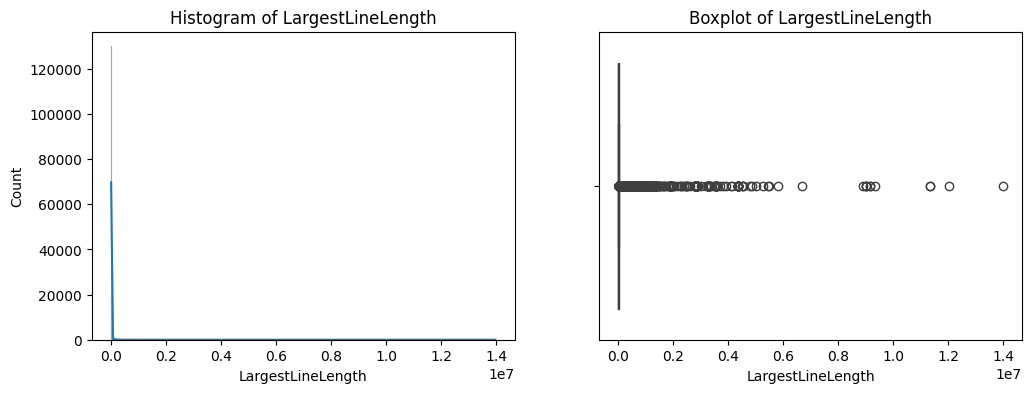

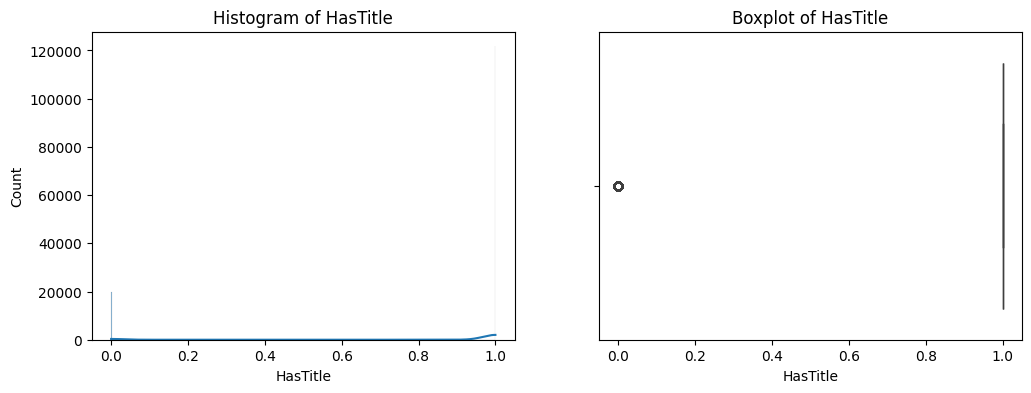

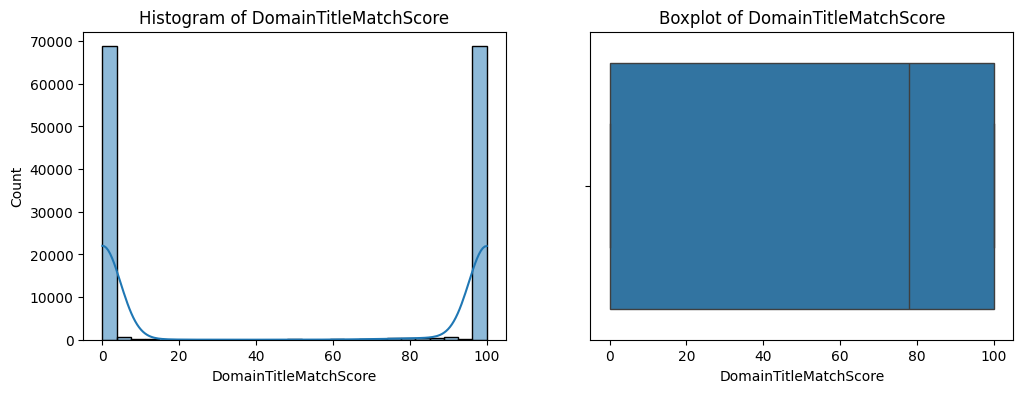

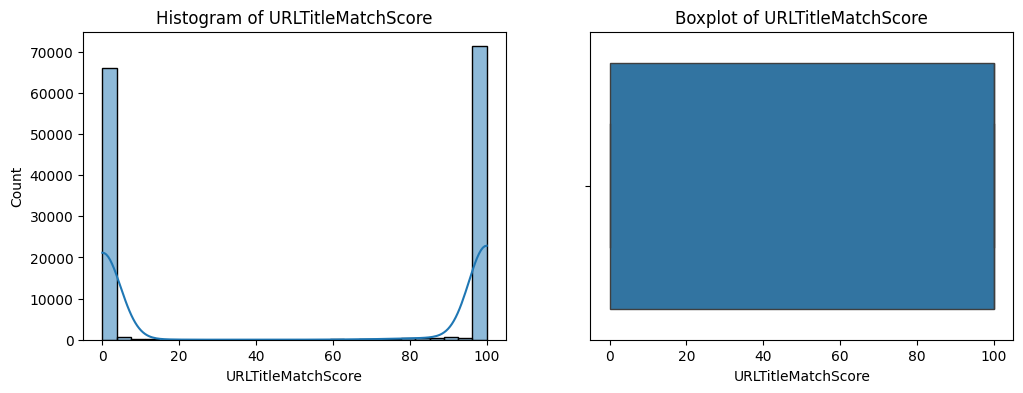

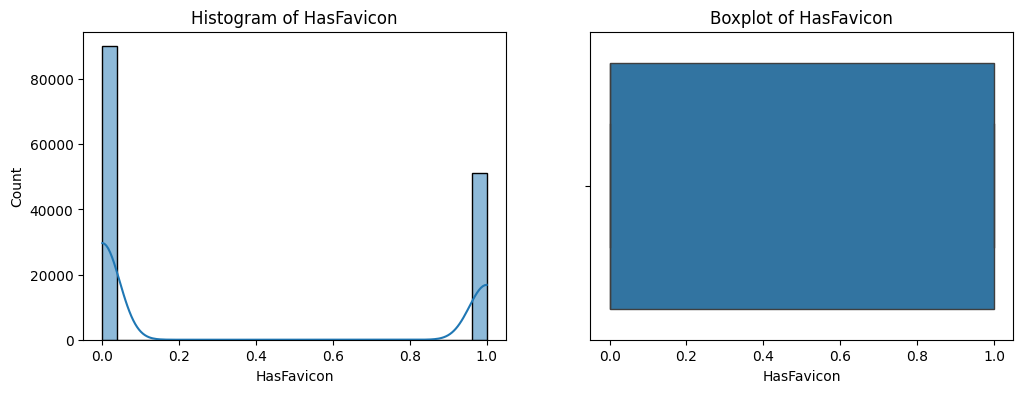

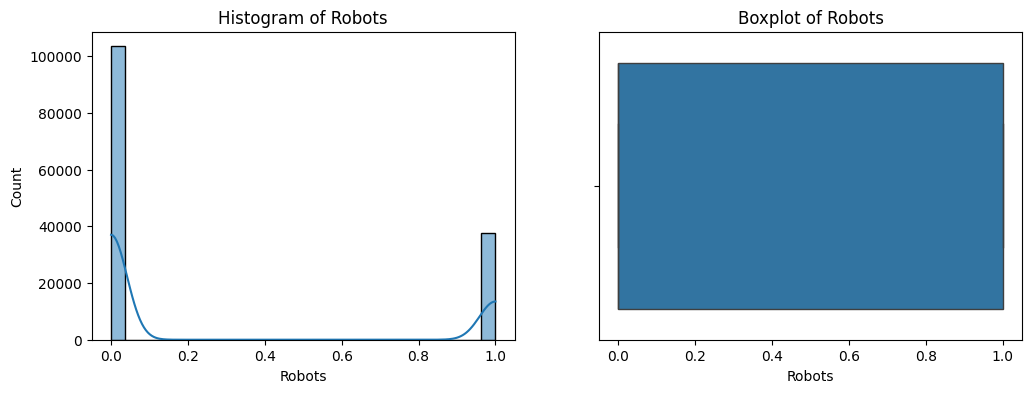

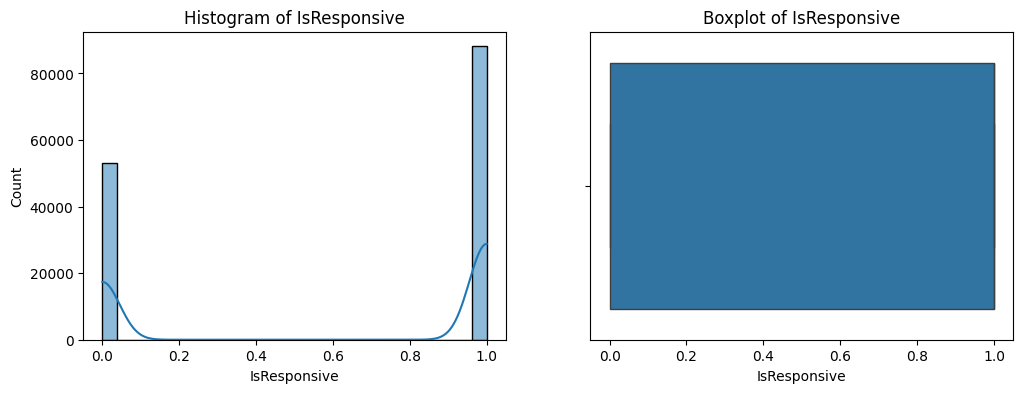

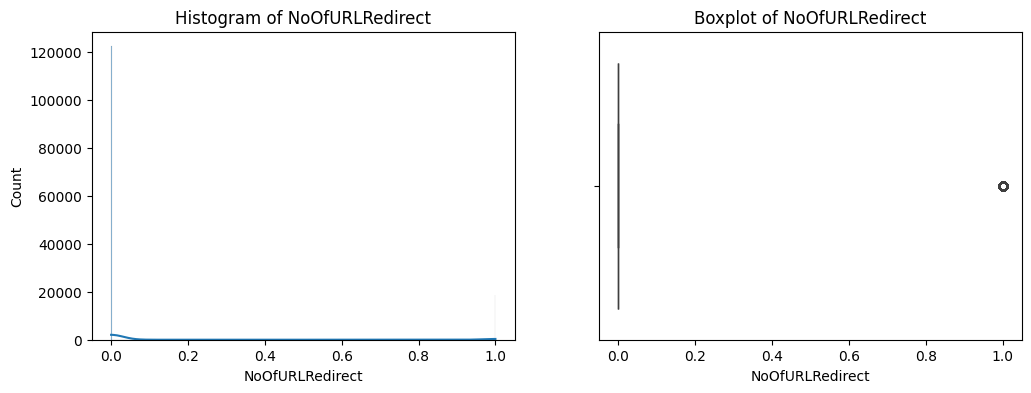

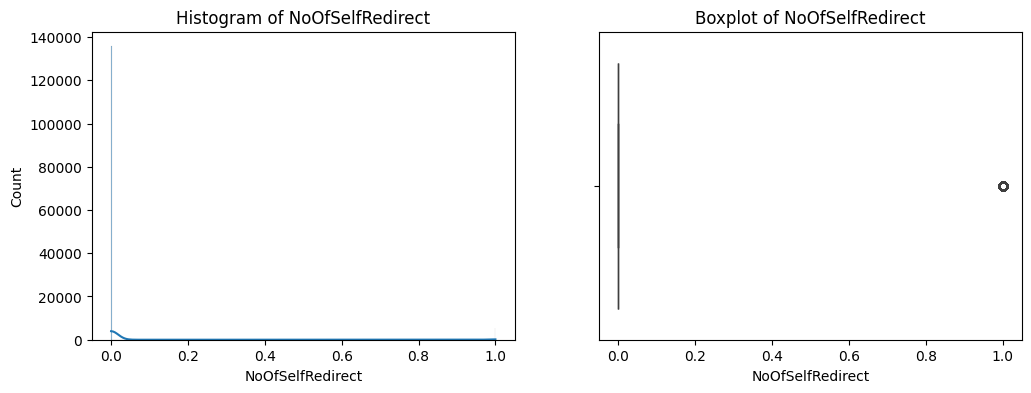

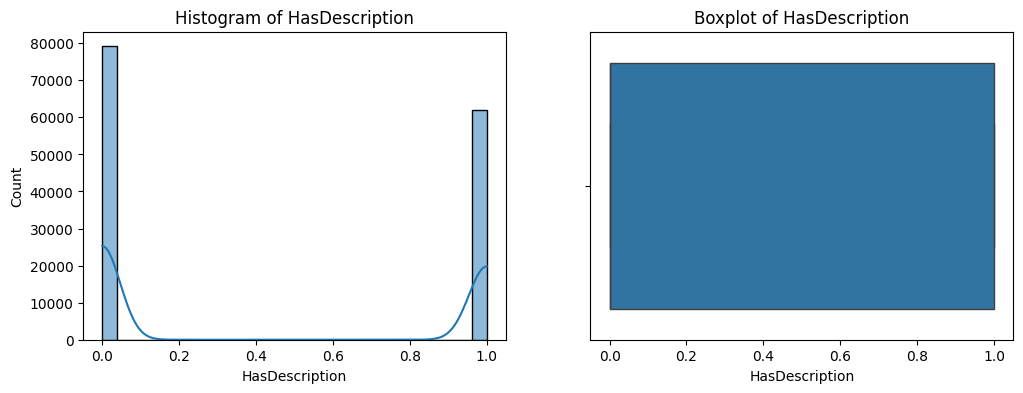

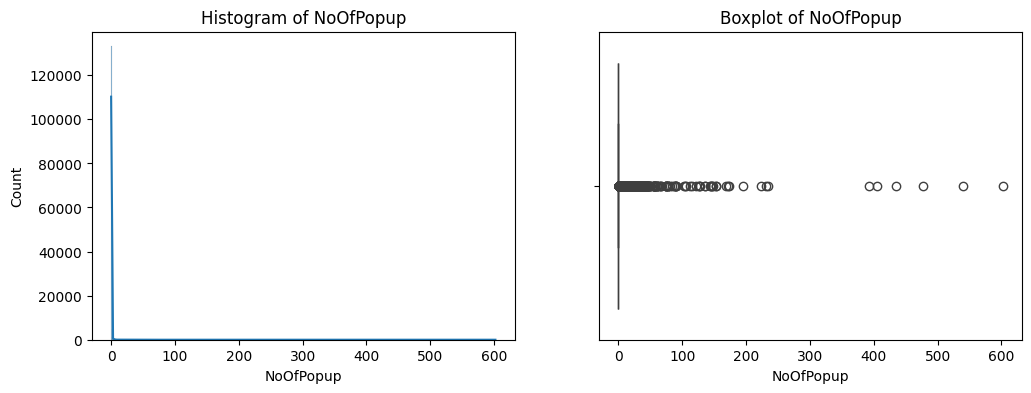

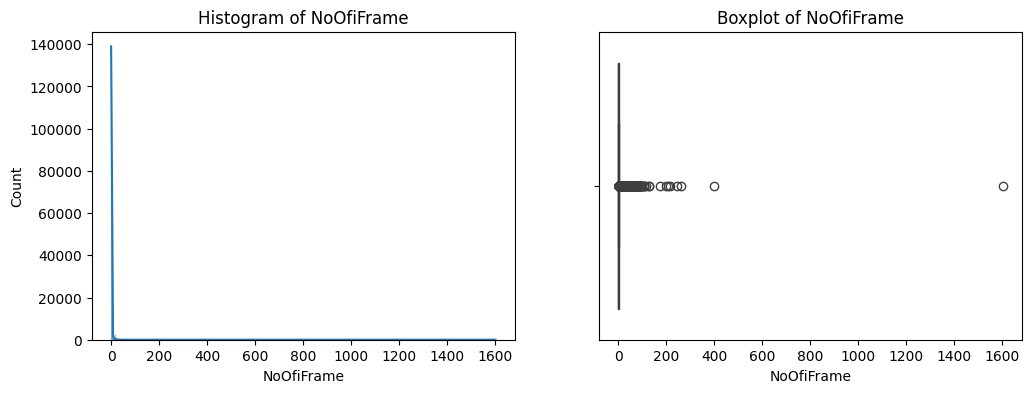

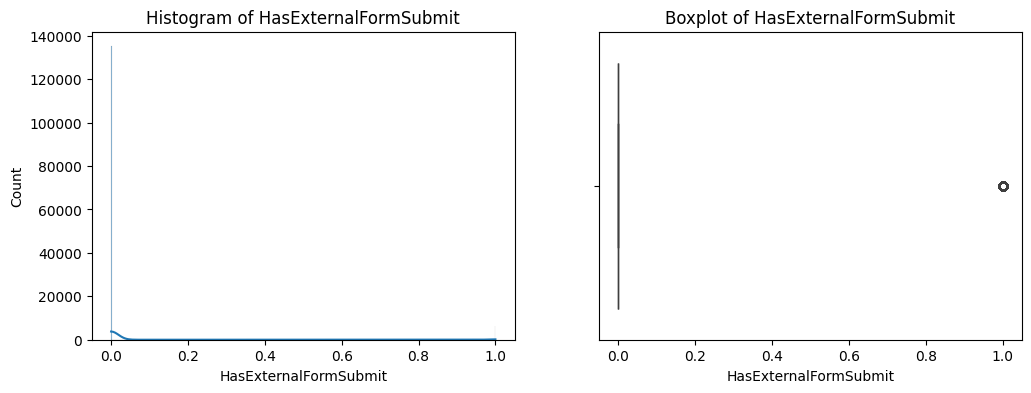

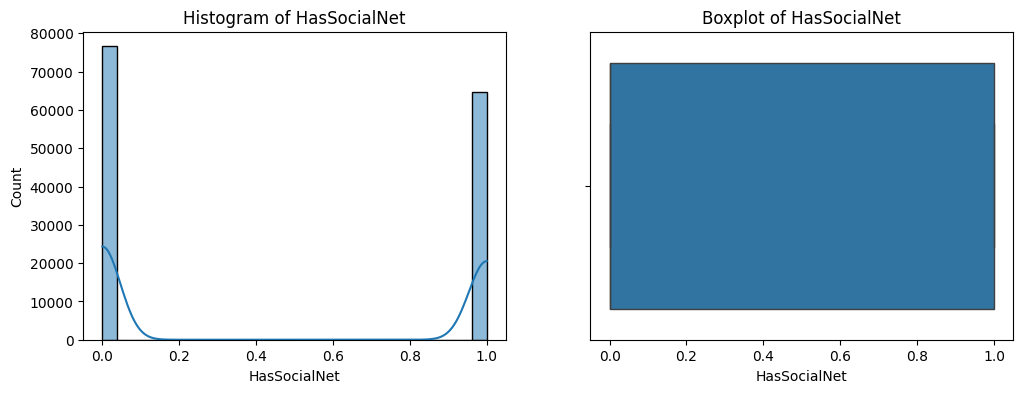

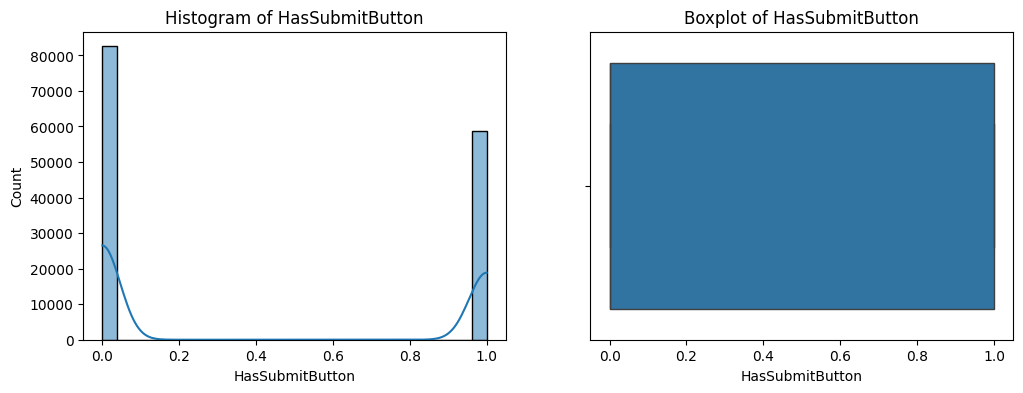

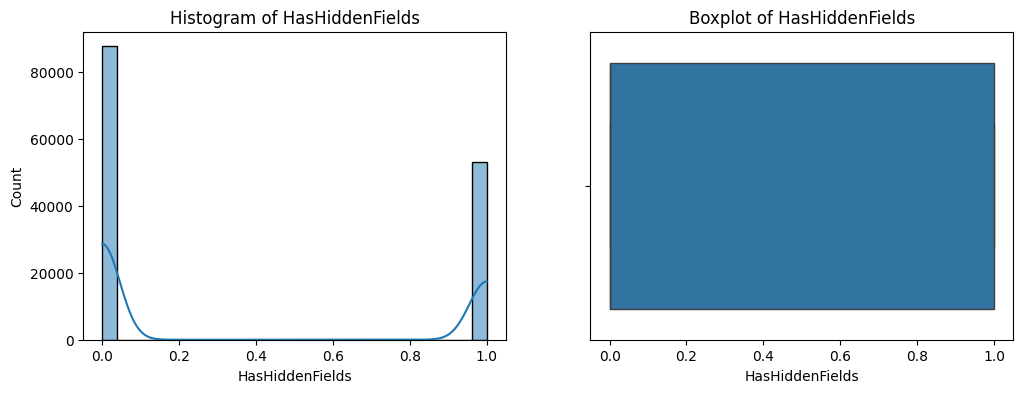

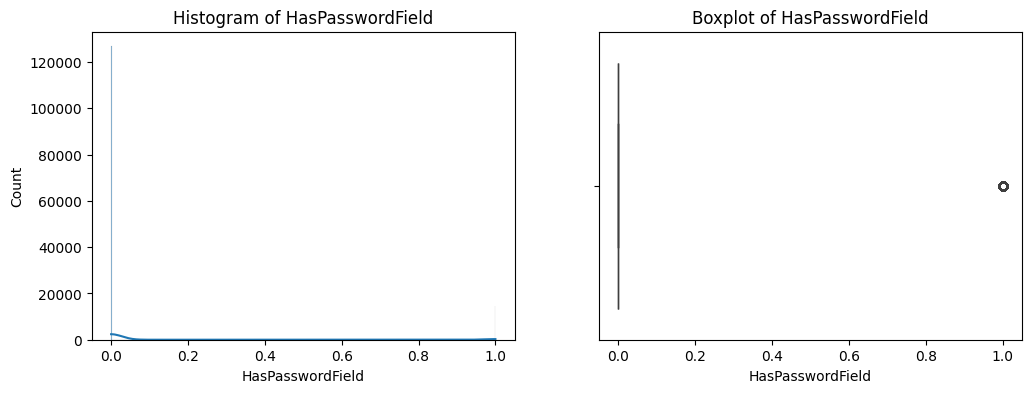

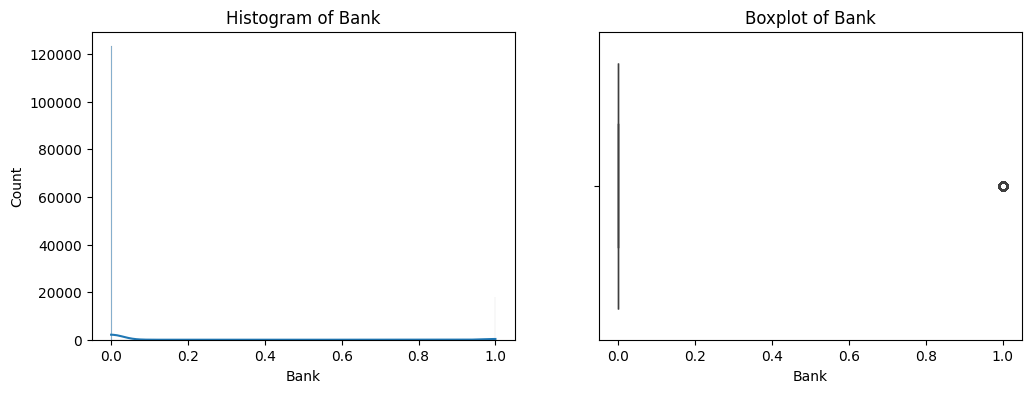

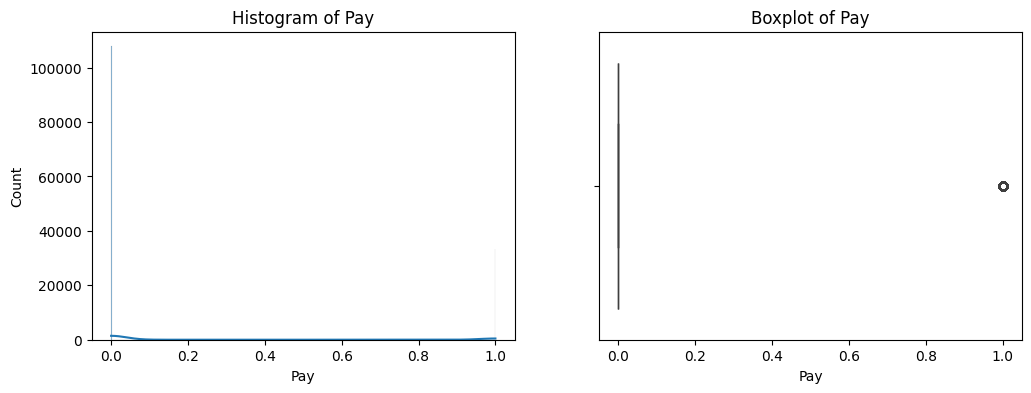

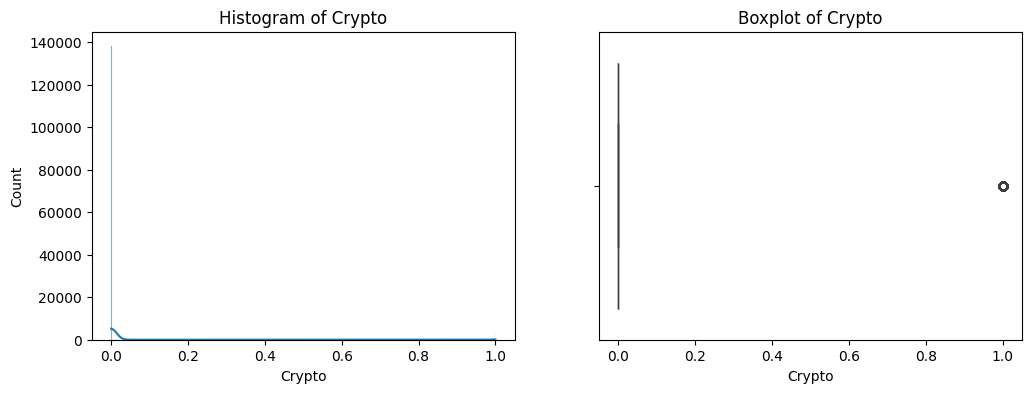

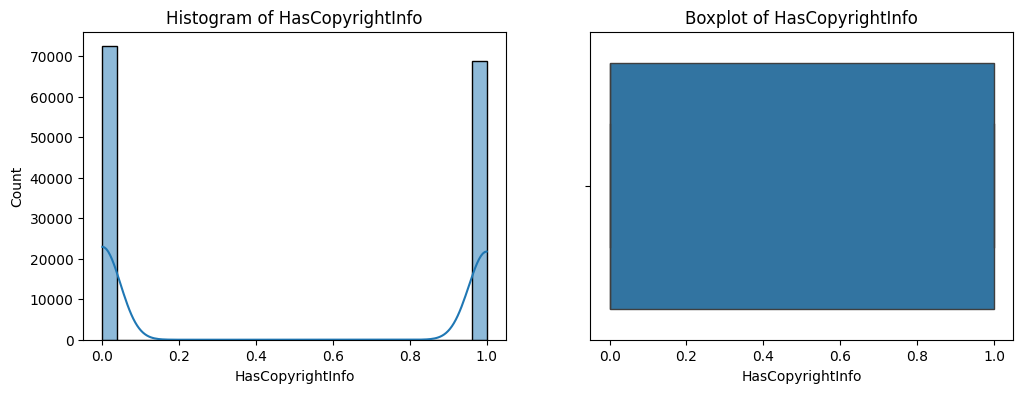

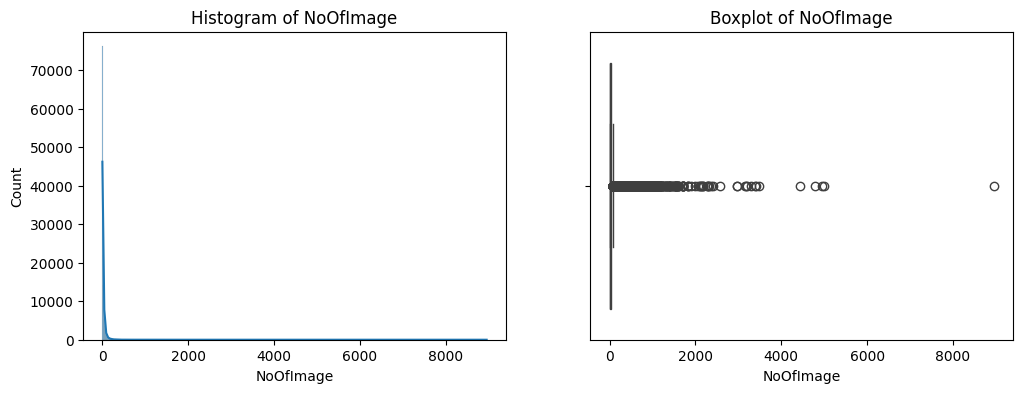

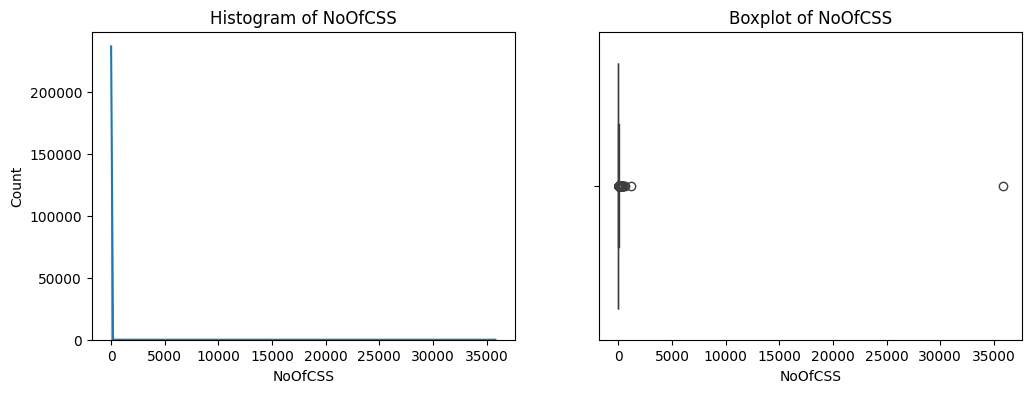

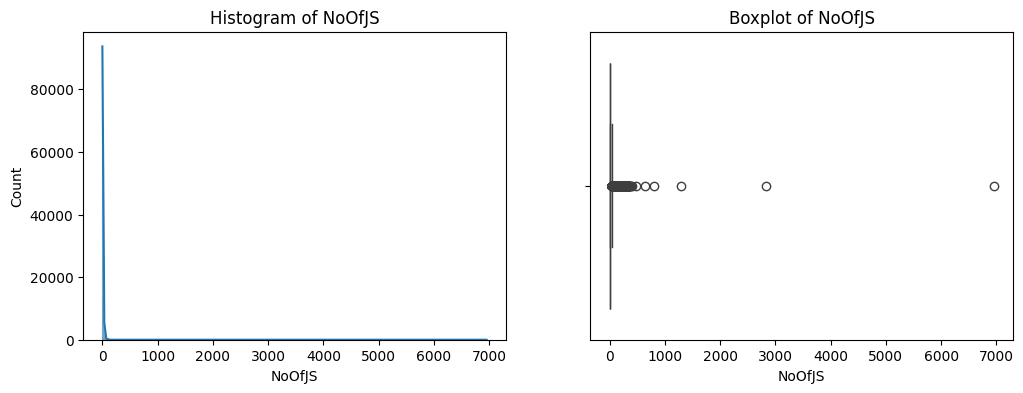

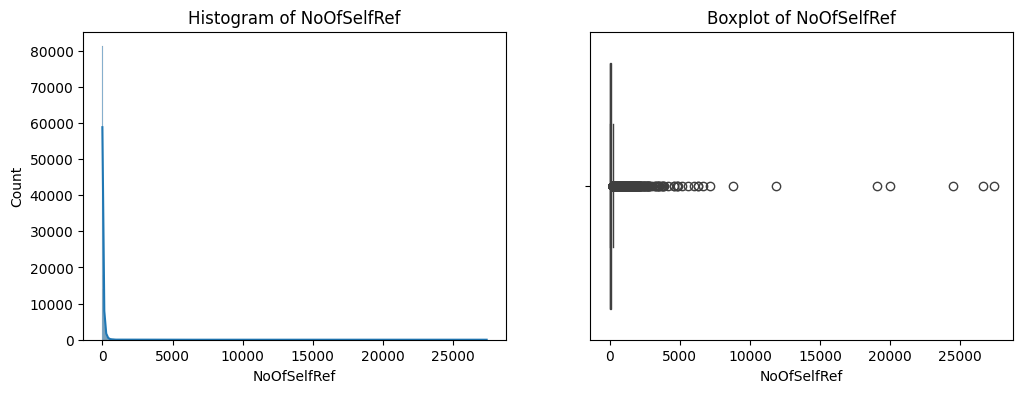

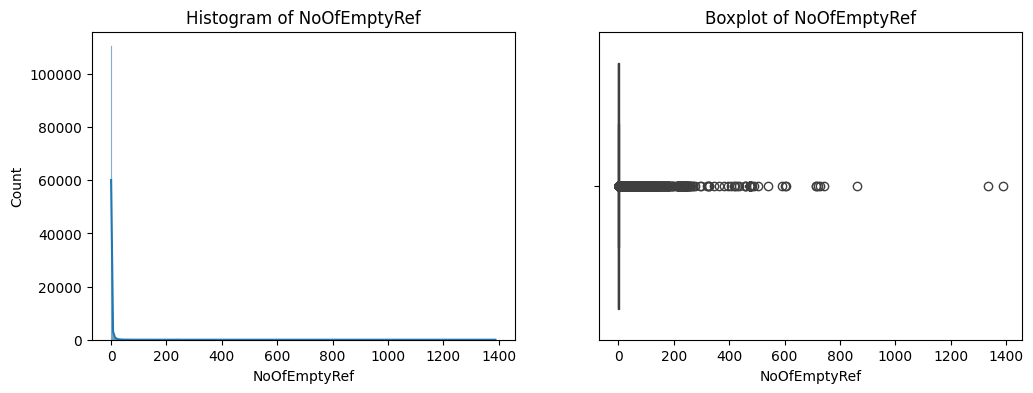

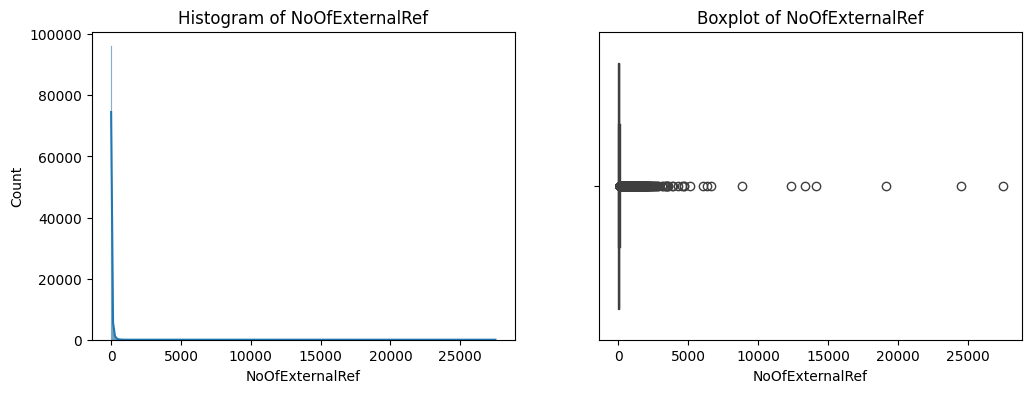

In [6]:
# Summary statistics for numerical columns
num_summary = df[num_cols].describe().T
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

Comment: We have outliers for almost every numeric columns exceptt binary columns. We need to look in Feature Engineering part to arrange the data model.

Correlation Matrix-Heatmap

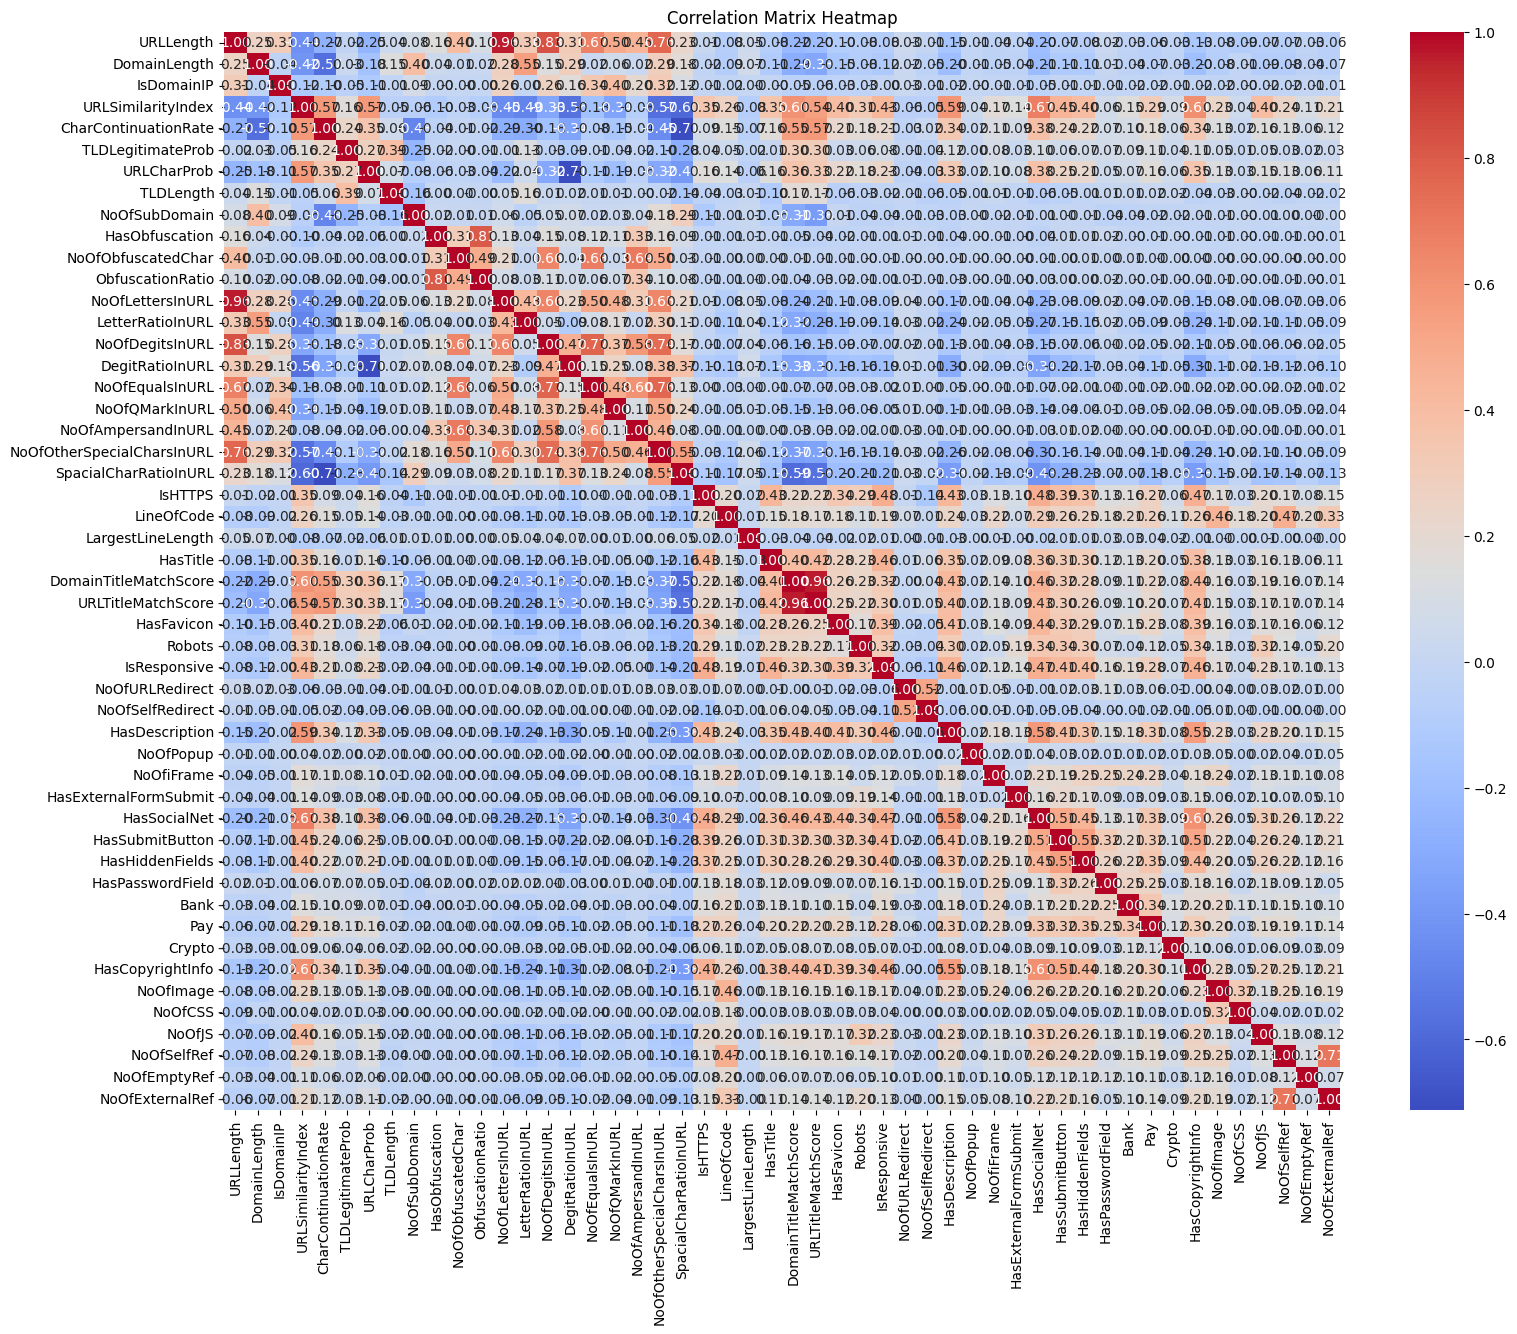

In [ ]:
#corr matrix, heat map
corr = df[num_cols].corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

Comments: The correlation matrix exhibits significant sparsity, characterized by low correlations across the majority of features (indicated by the prevalence of blue tones). Strong correlations are scarce and clustered within specific subsets of features. This suggests that the features provide independent information, which is advantageous for model performance.

Next, we filter variables using a correlation threshold and plot a focused correlation matrix for better interpretability.

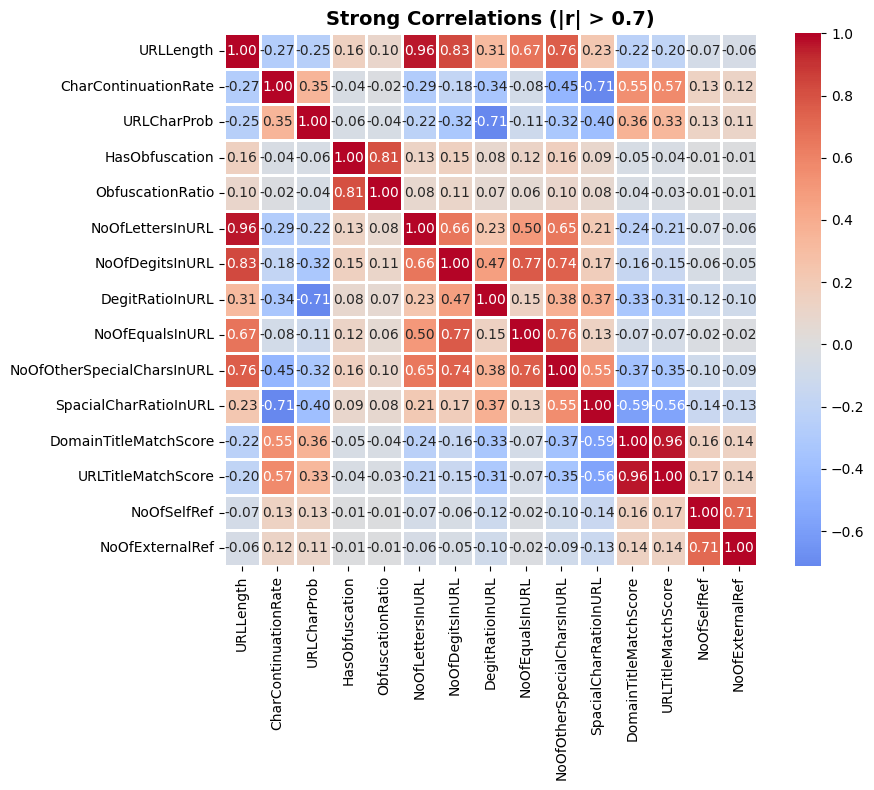

In [10]:
# Filter strong correlations, and visualize
threshold = 0.7
corr_matrix = df[num_cols].corr()

# Find features with strong correlation
mask = (corr_matrix.abs() > threshold) & (corr_matrix != 1.0)
strong_features = corr_matrix.columns[mask.any()].tolist()

# Matrix of strong correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df[strong_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title(f'Strong Correlations (|r| > {threshold})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Comments: Strong correlation between features can be handle in feature enginerring part. Firstly, we want to look at closely on which features have effect on our target variable. We see this information on heatmap above on for label but we want to look closely. 

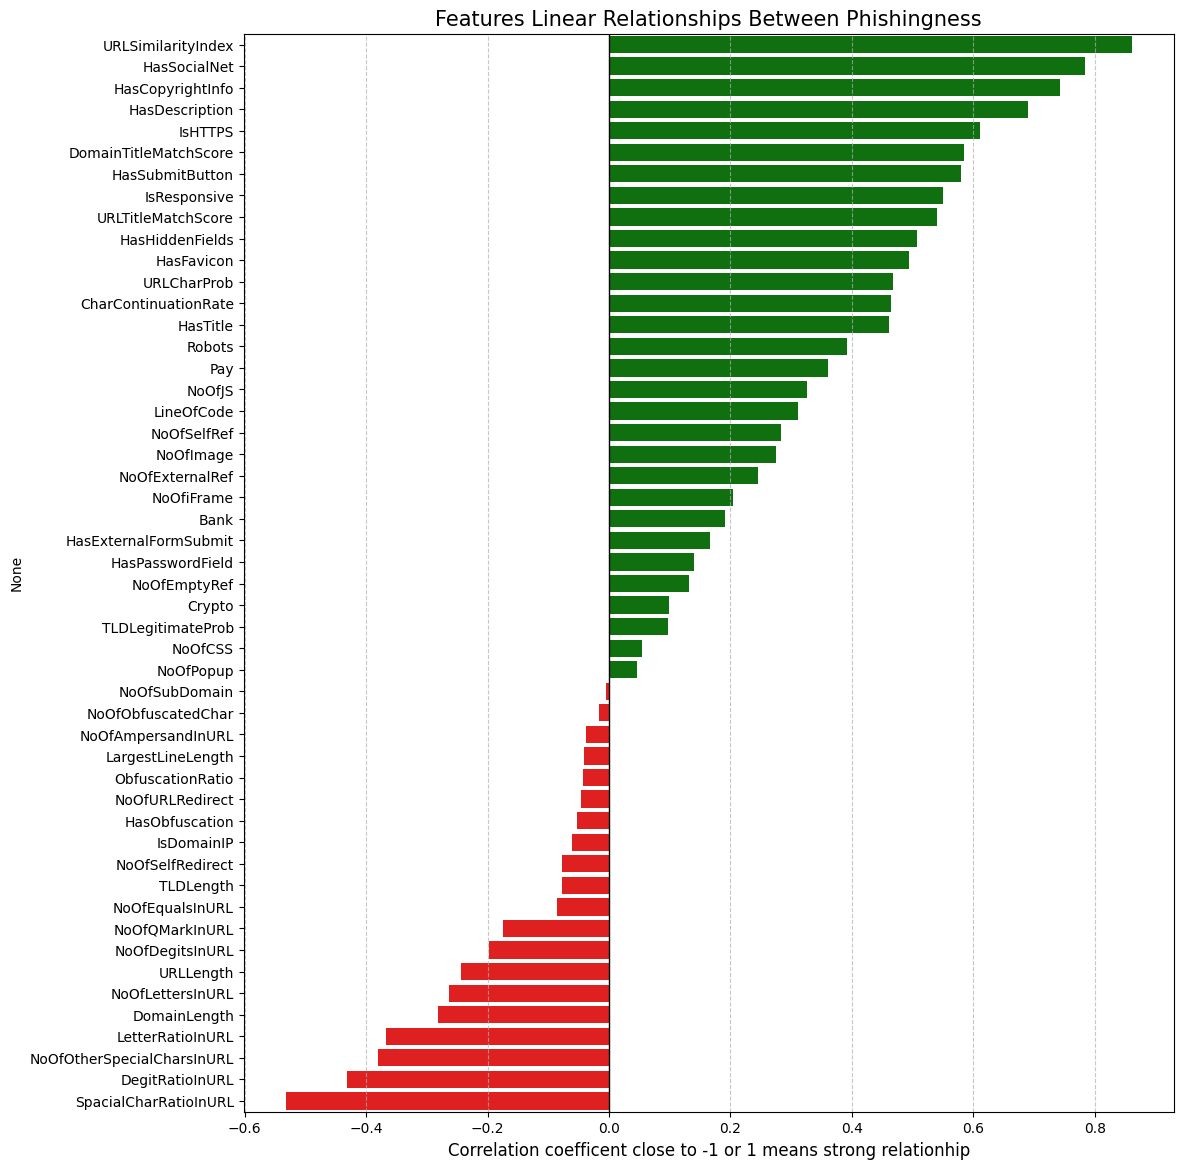

In [23]:
num_df = df[num_cols.tolist() + ['label']]
target_corr = num_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')
plt.figure(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in target_corr.values] # (Green:Positive, Red: Negative)
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette=colors, legend=False)

plt.title('Features Linear Relationships Between Phishingness', fontsize=15)
plt.xlabel('Correlation coefficent close to -1 or 1 means strong relationhip', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Black line in the middle
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comments: Green denotes a positive correlation, while red indicates a negative one. The features displayed are selected based on their strong relationship with the target label. For instance, the presence of social networking content (HasSocialNet) exhibits a strong positive correlation with phishing. This suggests that websites containing more social networking links are significantly more likely to be phishing sites.

Looking For Binary Columns Closely

In [15]:
#Picking up most important features binaries from EDA and feature selection
#Temporarily drop the NA values ​​(for this analysis only)
df_temp = df.dropna()
X_train = df_temp.drop(columns=['label'])
y_train = df_temp['label']
#most important 4 binary features distribution by label
from sklearn.feature_selection import SelectKBest, chi2

# 1. IDENTIFY ALL BINARY COLUMNS
# We assume binary columns have exactly 2 unique values (0 and 1)
print(f"Total Binary Features Detected: {len(binary_columns)}")

# 2. SCORE THEM (Chi-Squared Test)
# Chi2 is the best statistical test for Binary Feature vs Binary Target
selector = SelectKBest(score_func=chi2, k=4)

# We fit ONLY on the binary columns of the training set
selector.fit(X_train[binary_columns], y_train)

# 3. GET THE WINNERS
# Get the boolean mask of the selected top 4
mask = selector.get_support()
# Filter the list of names using the mask
top_4_binary = [binary_columns[i] for i in range(len(binary_columns)) if mask[i]]

print("\n THE TOP 4 MOST IMPORTANT BINARY FEATURES:")
for feature in top_4_binary:
    print(f" - {feature}")

Total Binary Features Detected: 17

 THE TOP 4 MOST IMPORTANT BINARY FEATURES:
 - HasCopyrightInfo
 - HasDescription
 - HasSocialNet
 - HasSubmitButton


Comment: As illustrated in the 'Features Linear Relationships' graph, the results align with those obtained from the Chi-Squared test. These four binary features identify phishing sites effectively and will be key for our model. The formal selection of these features and the exclusion of others will be addressed in the Feature Selection section.